# Assignment 3 - Factors, PCA, Copulas and EVT

__Authors: Team 20__<br>

Andreas: Copulas <br>
Hamza: Copulas <br>
Shubham: Factor Analysis <br>
Milan: EVT <br>
Siddharth: Setup and PCA 



## Setup - Data Loading and Cleaning

In [26]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import itertools
import matplotlib.patches as mpatches

#  Asset universe: 3 stocks | 2 bond ETFs | 2 indices | 3 commodity ETFs 
assets = {
    # Stocks (large-cap, different sectors)
    "ASML":    "ASML.AS",    # Tech/semis
    "Shell":   "SHELL.AS",    # Energy
    "Walmart": "WMT",     # Consumer staples

    # Bonds (via ETFs — EUR sovereign + corp)
    "USTB":  "BND",    # iShares EUS Treasury Bond ETF
    "EUB": "SYBB.DE",    # State Street Euro Government Bond ETF

    # Indices
    "AEX":     "^AEX",       # Dutch equity index
    "SP500":   "^GSPC",      # US equity index

    # Commodities (via ETFs)
    "Gold":    "GLD",        # Gold
    "Oil":     "USO",        # WTI Crude Oil ETF
    "Iron":  "XME",       # Iron
}

tickers = list(assets.values())
names   = list(assets.keys())

raw = yf.download(tickers, start="2017-01-01", end="2026-04-30",
                  auto_adjust=True, progress=False)["Close"]
print(raw.head())

ticker_to_name = {v: k for k, v in assets.items()}
raw = raw.rename(columns=ticker_to_name)

# Drop any rows with more than 3 NaN (aligns all series to common trading days)
print(f"\nRaw NaN counts:\n{raw.isnull().sum().to_string()}")
prices_clean = raw.copy()
drop_mask = prices_clean.isnull().sum(axis=1) >= 3
prices_clean = prices_clean[~drop_mask]
print(f"\nRows dropped: {drop_mask.sum()}")

# Gap lengths after drop
print("\nNaN counts and max consecutive gap after drop:")
for col in prices_clean.columns:
    s = prices_clean[col]
    total = s.isnull().sum()
    max_gap = max((sum(1 for _ in g) for v, g in itertools.groupby(s.isnull()) if v), default=0)
    print(f"  {col:12s}  nans: {total:3d}  max_gap: {max_gap}")

prices_clean = prices_clean.dropna()

# Log returns
returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

print(f"Shape: {returns.shape})")
returns.describe().T[["mean","std","min","max","count"]].round(4)

Ticker        ASML.AS        BND         GLD   SHELL.AS    SYBB.DE        USO  \
Date                                                                            
2017-01-02  97.624039        NaN         NaN  16.159502  57.799656        NaN   
2017-01-03  97.213669  61.247494  110.470001  16.353640  57.375484  91.519997   
2017-01-04  95.891335  61.292934  110.860001  16.433762  57.255596  92.639999   
2017-01-05  96.119339  61.603703  112.580002  16.350557  57.117290  93.599998   
2017-01-06  96.119339  61.361153  111.750000  16.285845  57.052738  93.440002   

Ticker            WMT        XME        ^AEX        ^GSPC  
Date                                                       
2017-01-02        NaN        NaN  486.369995          NaN  
2017-01-03  19.551619  27.618250  487.989990  2257.830078  
2017-01-04  19.665522  28.630947  487.579987  2270.750000  
2017-01-05  19.708237  29.012939  486.929993  2269.000000  
2017-01-06  19.437712  28.248972  487.000000  2276.979980  

Raw NaN cou

,mean,std,min,max,count
Ticker,,,,,
ASML,0.0011,0.0222,-0.1701,0.1170,2302.0
USTB,0.0001,0.0036,-0.0559,0.0413,2302.0
Gold,0.0006,0.0102,-0.1084,0.0616,2302.0
Shell,0.0004,0.0183,-0.1922,0.2026,2302.0
EUB,-0.0000,0.0035,-0.0178,0.0233,2302.0
Oil,0.0002,0.0252,-0.2919,0.1542,2302.0
Walmart,0.0008,0.0139,-0.1208,0.1107,2302.0
Iron,0.0006,0.0208,-0.1607,0.1197,2302.0
AEX,0.0003,0.0104,-0.1138,0.0859,2302.0


__Correlation Heatmap__

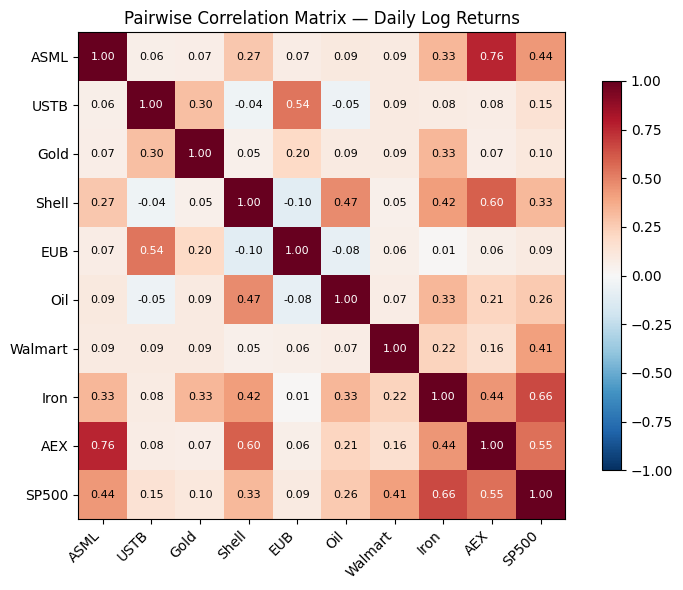

In [27]:

corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(xticks=range(len(corr)), xticklabels=corr.columns,
       yticks=range(len(corr)), yticklabels=corr.columns,
       title="Pairwise Correlation Matrix — Daily Log Returns")
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


__Annualised Volatility__

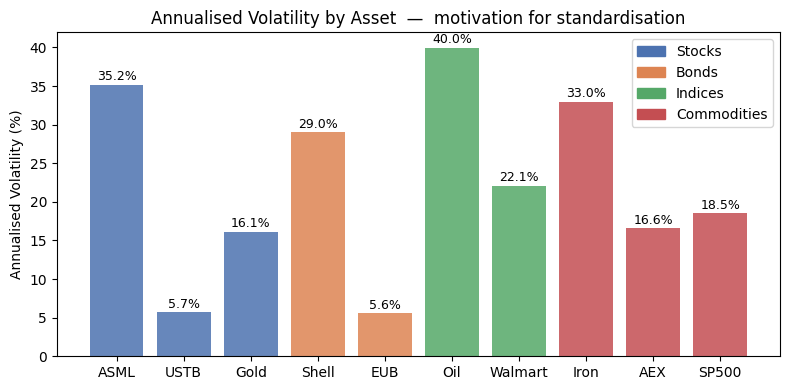

In [28]:
ann_vol = returns.std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0"]*3 + ["#DD8452"]*2 + ["#55A868"]*2 + ["#C44E52"]*3
bars = ax.bar(ann_vol.index, ann_vol.values * 100, color=colors, alpha=0.85)
for bar, val in zip(bars, ann_vol.values * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set(ylabel="Annualised Volatility (%)",
       title="Annualised Volatility by Asset  —  motivation for standardisation")

# Asset class legend
from matplotlib.patches import Patch
legend = [Patch(color="#4C72B0", label="Stocks"),
          Patch(color="#DD8452", label="Bonds"),
          Patch(color="#55A868", label="Indices"),
          Patch(color="#C44E52", label="Commodities")]
ax.legend(handles=legend, loc="upper right")
plt.tight_layout()
plt.show()

__Covariance vs Correlation__

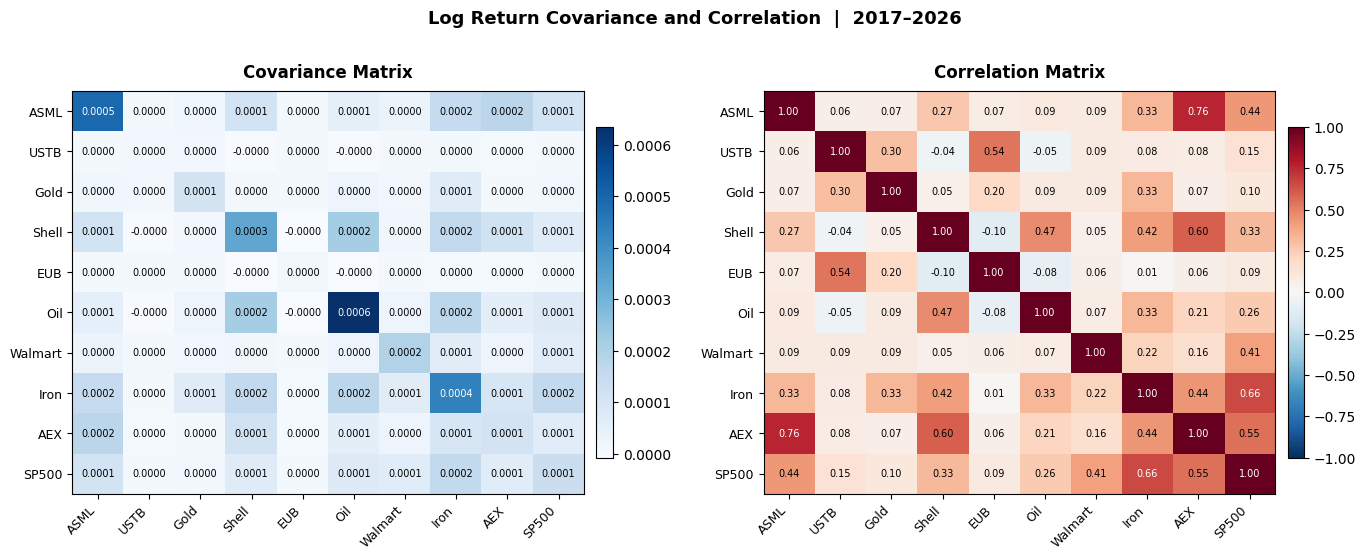

In [29]:
asset_names = returns.columns.tolist()
cov_matrix  = returns.cov()
corr_matrix = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plt.subplots_adjust(wspace=0.08)

def draw_heatmap(ax, mat, title, fmt, vmin, vmax, cmap):
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(asset_names)))
    ax.set_xticklabels(asset_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(asset_names)))
    ax.set_yticklabels(asset_names, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    for i in range(len(asset_names)):
        for j in range(len(asset_names)):
            val = mat.values[i, j]
            txt_col = 'white' if abs(val) > abs(vmax) * 0.65 else 'black'
            ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=7, color=txt_col)
    plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02)

draw_heatmap(axes[0], cov_matrix,  'Covariance Matrix',  '{:.4f}',
             vmin=cov_matrix.values.min(), vmax=cov_matrix.values.max(), cmap='Blues')
draw_heatmap(axes[1], corr_matrix, 'Correlation Matrix', '{:.2f}',
             vmin=-1, vmax=1, cmap='RdBu_r')

plt.suptitle('Log Return Covariance and Correlation  |  2017–2026',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

__Cumulative Returns__

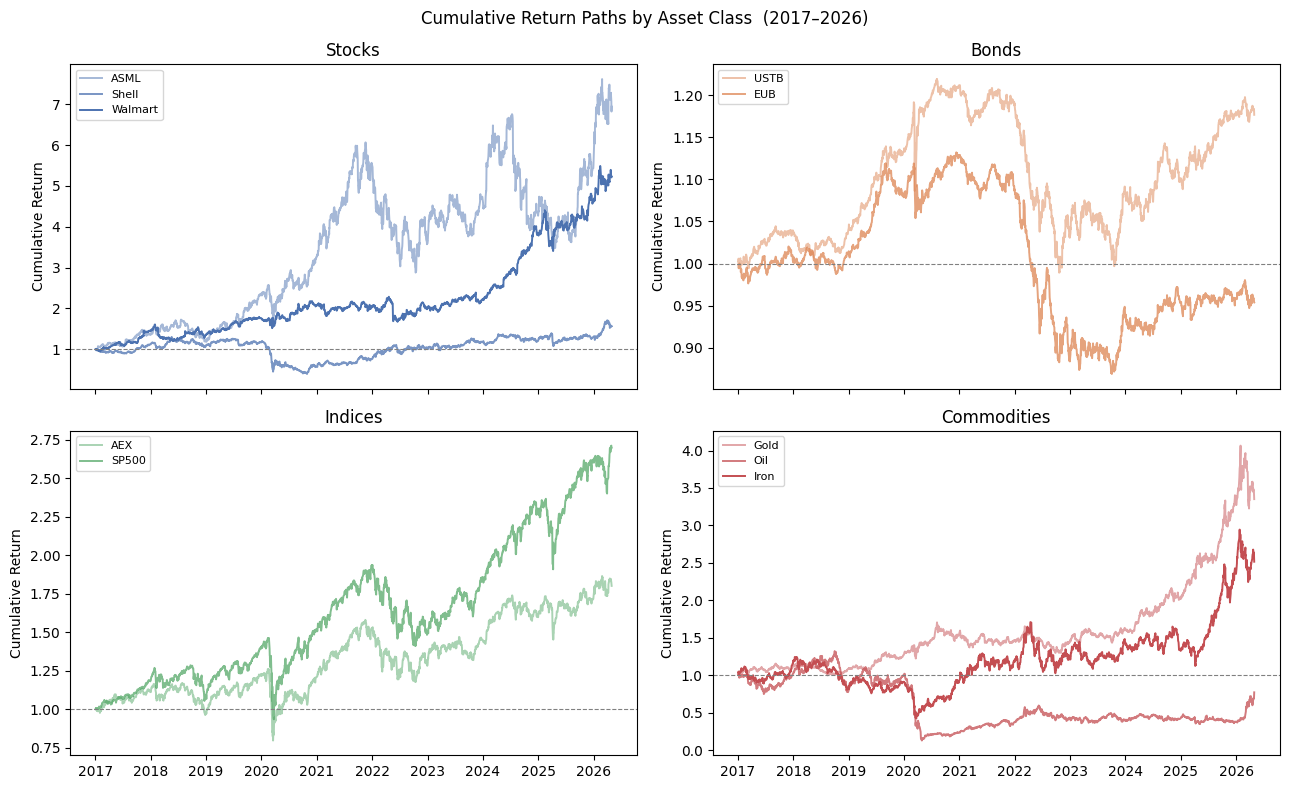

In [30]:
cum_returns = (1 + returns).cumprod()

asset_classes = {
    "Stocks":      ["ASML", "Shell", "Walmart"],
    "Bonds":       ["USTB", "EUB"],
    "Indices":     ["AEX", "SP500"],
    "Commodities": ["Gold", "Oil", "Iron"],
}
colors_map = {"Stocks": "#4C72B0", "Bonds": "#DD8452",
              "Indices": "#55A868", "Commodities": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (cls, members) in zip(axes.flat, asset_classes.items()):
    for asset in members:
        ax.plot(cum_returns.index, cum_returns[asset],
                label=asset, color=colors_map[cls],
                alpha=0.5 + 0.25 * members.index(asset),
                linewidth=1.4)
    ax.set(title=cls, ylabel="Cumulative Return")
    ax.legend(fontsize=8)
    ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)

plt.suptitle("Cumulative Return Paths by Asset Class  (2017–2026)", fontsize=12)
plt.tight_layout()
plt.show()

__Asset Correlations__

In [31]:
print("  WITHIN-GROUP average correlations")
print("─" * 52)
for cls, members in asset_classes.items():
    if len(members) > 1:
        pairs = [(i, j) for i in members for j in members if i < j]
        avg_corr = np.mean([corr.loc[i, j] for i, j in pairs])
        print(f"  {cls:<14}  avg ρ = {avg_corr:.3f}")

print()
print("  CROSS-GROUP average correlations")
print("─" * 52)
class_list = list(asset_classes.keys())
for i in range(len(class_list)):
    for j in range(i+1, len(class_list)):
        g1, g2 = class_list[i], class_list[j]
        m1, m2 = asset_classes[g1], asset_classes[g2]
        avg_cross = np.mean([corr.loc[a, b] for a in m1 for b in m2])
        print(f"  {g1:<12} × {g2:<12}  avg ρ = {avg_cross:.3f}")

  WITHIN-GROUP average correlations
────────────────────────────────────────────────────
  Stocks          avg ρ = 0.138
  Bonds           avg ρ = 0.536
  Indices         avg ρ = 0.554
  Commodities     avg ρ = 0.252

  CROSS-GROUP average correlations
────────────────────────────────────────────────────
  Stocks       × Bonds         avg ρ = 0.023
  Stocks       × Indices       avg ρ = 0.449
  Stocks       × Commodities   avg ρ = 0.203
  Bonds        × Indices       avg ρ = 0.095
  Bonds        × Commodities   avg ρ = 0.078
  Indices      × Commodities   avg ρ = 0.291


## PCA

Eigenvalues (sorted): [3.2643 1.7617 1.1559 1.0664 0.8266 0.5869 0.5088 0.4455 0.2462 0.1333]


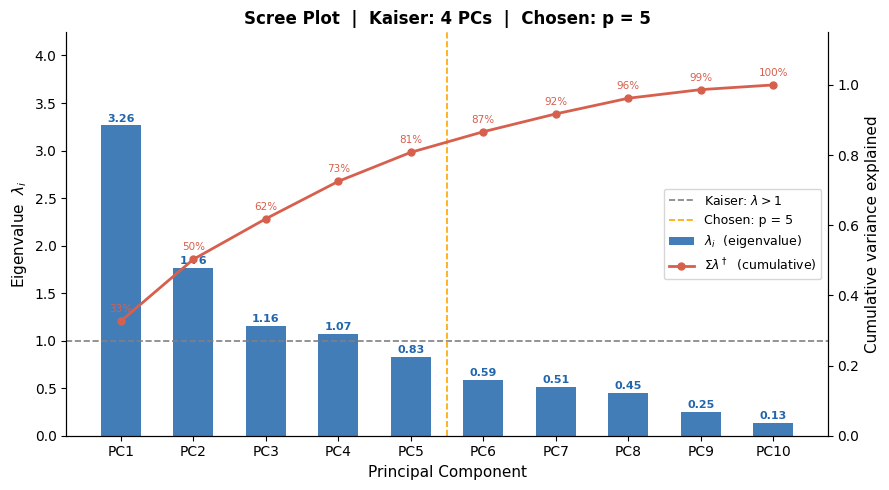

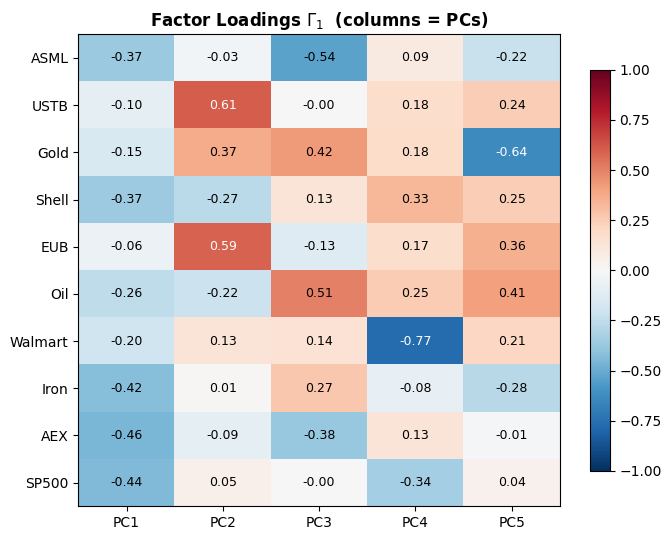

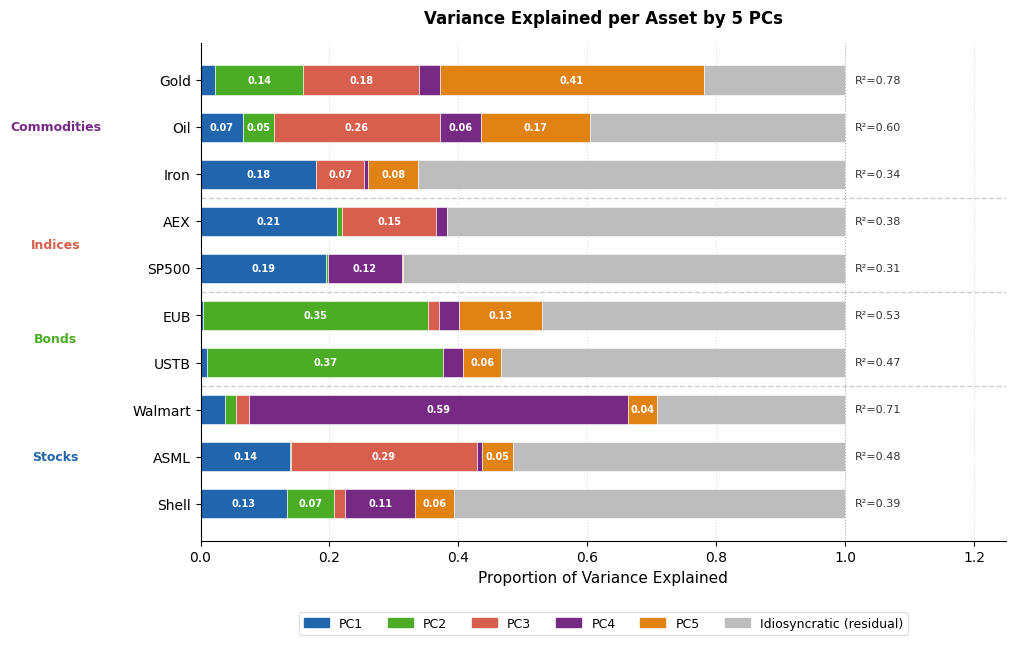

In [32]:
# Standardise returns
X_tilde = (returns - returns.mean()) / returns.std()

# Correlation matrix
n = len(X_tilde)
A = (X_tilde.T @ X_tilde) / n

# Eigendecomposition, sorted largest to smallest
eigenvalues_raw, eigenvectors_raw = np.linalg.eig(A)
order        = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[order].real
eigenvectors = eigenvectors_raw[:, order].real
print("Eigenvalues (sorted):", np.round(eigenvalues, 4))

# Normalise eigenvectors to unit length
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# Variance explained
d                = len(eigenvalues)
var_explained    = eigenvalues / eigenvalues.sum()
cumvar_explained = np.cumsum(var_explained)

n_kaiser = int((eigenvalues > 1).sum())
n_90pct  = int(np.searchsorted(cumvar_explained, 0.90) + 1)
p        = 5

# Scree plot
all_labels = [f'PC{i+1}' for i in range(len(eigenvalues))]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars = ax1.bar(all_labels, eigenvalues, color='#2166AC', alpha=0.85,
               width=0.55, label=r'$\lambda_i$  (eigenvalue)')
for bar, v in zip(bars, eigenvalues):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{v:.2f}', ha='center', va='bottom', fontsize=8,
             color='#2166AC', fontweight='bold')

ax2.plot(all_labels, cumvar_explained, color='#D6604D', marker='o',
         linewidth=2, markersize=5, label=r'$\Sigma\lambda^\dagger$  (cumulative)')
for i, cv in enumerate(cumvar_explained):
    ax2.text(i, cv + 0.02, f'{cv*100:.0f}%', ha='center', va='bottom',
             fontsize=7.5, color='#D6604D')

ax1.axhline(1.0, color='gray', linestyle='--', linewidth=1.2,
            label='Kaiser: $\\lambda > 1$')
ax1.axvline(p - 0.5, color='orange', linestyle='--', linewidth=1.2,
            label=f'Chosen: p = {p}')

ax1.set_ylabel(r'Eigenvalue  $\lambda_i$', fontsize=11)
ax1.set_xlabel('Principal Component', fontsize=11)
ax2.set_ylabel(r'Cumulative variance explained', fontsize=11)
ax2.set_ylim(0, 1.15)
ax1.set_ylim(0, eigenvalues.max() * 1.3)
ax1.set_title(f'Scree Plot  |  Kaiser: {n_kaiser} PCs  |  Chosen: p = {p}',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

# Factor loadings and scores
Gamma_1 = eigenvectors[:, :p]
F_hat   = pd.DataFrame(
    X_tilde.values @ Gamma_1,
    index=returns.index,
    columns=[f'PC{i+1}' for i in range(p)]
)

loadings = pd.DataFrame(Gamma_1, index=asset_names,
                        columns=[f'PC{i+1}' for i in range(p)])

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(p))
ax.set_xticklabels(loadings.columns, fontsize=10)
ax.set_yticks(range(len(asset_names)))
ax.set_yticklabels(asset_names, fontsize=10)
ax.set_title(r'Factor Loadings $\Gamma_1$  (columns = PCs)',
             fontsize=12, fontweight='bold')
for i in range(len(asset_names)):
    for j in range(p):
        val = loadings.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(val) > 0.55 else 'black')
plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

# Variance decomposition
Sigma_factor = Gamma_1 @ Gamma_1.T
Upsilon      = A - Sigma_factor
R2_per_asset = pd.Series(np.diag(Sigma_factor) / np.diag(A), index=asset_names)

# R² stacked bar chart
R2_contributions = pd.DataFrame(
    Gamma_1 ** 2 / np.diag(A)[:, None],
    index=asset_names,
    columns=[f'PC{j+1}' for j in range(p)]
)
R2_total = R2_contributions.sum(axis=1)

asset_types = {
    'Stocks':      ['ASML', 'Shell', 'Walmart'],
    'Bonds':       ['USTB', 'EUB'],
    'Indices':     ['AEX', 'SP500'],
    'Commodities': ['Gold', 'Oil', 'Iron'],
}
ordered_assets, group_boundaries = [], []
idx = 0
for label, members in asset_types.items():
    sorted_m = R2_total[members].sort_values(ascending=True).index.tolist()
    ordered_assets.extend(sorted_m)
    group_boundaries.append((idx, idx + len(sorted_m) - 1, label))
    idx += len(sorted_m)

R2_plot = R2_contributions.loc[ordered_assets]
R2_idio = 1.0 - R2_plot.sum(axis=1)

pc_colors   = ['#2166AC', '#4DAC26', '#D6604D', '#762A83', '#E08214']
type_colors = {'Stocks':'#2166AC', 'Bonds':'#4DAC26',
               'Indices':'#D6604D', 'Commodities':'#762A83'}

fig, ax = plt.subplots(figsize=(10, 6.5))
plt.subplots_adjust(left=0.22, right=0.88, top=0.88, bottom=0.18)

y_pos = np.arange(len(ordered_assets))
left  = np.zeros(len(ordered_assets))

for j in range(p):
    vals = R2_plot[f'PC{j+1}'].values
    ax.barh(y_pos, vals, left=left, height=0.62,
            color=pc_colors[j], label=f'PC{j+1}',
            edgecolor='white', linewidth=0.4)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 0.04:
            ax.text(l + v/2, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    left += vals

ax.barh(y_pos, R2_idio.values, left=left, height=0.62,
        color='#BDBDBD', label='Idiosyncratic (residual)',
        edgecolor='white', linewidth=0.4)
for i, (tot, l) in enumerate(zip(R2_plot.sum(axis=1).values, left)):
    ax.text(l + R2_idio.values[i] + 0.015, i,
            f'R²={tot:.2f}', va='center', fontsize=8, color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(ordered_assets, fontsize=10)
ax.set_xlim(0, 1.25)
ax.set_xlabel('Proportion of Variance Explained', fontsize=11)
ax.set_title(f'Variance Explained per Asset by {p} PCs',
             fontsize=12, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.axvline(1.0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.xaxis.grid(True, linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

for (start, end, label) in group_boundaries:
    mid_y = (start + end) / 2.0
    if start > 0:
        ax.axhline(start - 0.5, color='#CCCCCC', linewidth=1.0, linestyle='--', zorder=0)
    ax.annotate(label,
                xy=(0, mid_y), xycoords=('axes fraction', 'data'),
                xytext=(-0.18, mid_y), textcoords=('axes fraction', 'data'),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color=type_colors[label], annotation_clip=False)

legend_handles = [mpatches.Patch(color=pc_colors[j], label=f'PC{j+1}') for j in range(p)]
legend_handles.append(mpatches.Patch(color='#BDBDBD', label='Idiosyncratic (residual)'))
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.13), ncol=6,
          fontsize=9, framealpha=0.9, edgecolor='#DDDDDD')

plt.tight_layout()
plt.show()

## Factor Analysis


## Copulas

## EVT